In [1]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

path = "/content/drive/MyDrive/Colab Notebooks/archive"

print("Exists:", os.path.exists(path))
print("Is directory:", os.path.isdir(path))

Exists: True
Is directory: True


In [4]:
import os

for item in os.listdir("/content/drive/MyDrive/Colab Notebooks/archive"):
    print(item)

people.csv
matchpairsDevTrain.csv
matchpairsDevTest.csv
pairs.csv
lfw_readme.csv
mismatchpairsDevTest.csv
peopleDevTrain.csv
mismatchpairsDevTrain.csv
lfw_allnames.csv
peopleDevTest.csv
lfw-deepfunneled


In [5]:
import os

path = "/content/drive/MyDrive/Colab Notebooks/archive/lfw-deepfunneled"

print(os.listdir(path)[:20])

['lfw-deepfunneled']


In [6]:
import os

path = "/content/drive/MyDrive/Colab Notebooks/archive/lfw-deepfunneled/lfw-deepfunneled"

items = os.listdir(path)

print("Number of folders:", len(items))
print(items[:10])

Number of folders: 5784
['Chris_Klein', 'Chris_Gratton', 'Chris_Forsyth', 'Chris_Dodd', 'Chris_Crocker', 'Chris_Cornell', 'Chris_Cooper', 'Chris_Claiborne', 'Chris_Columbus', 'Chris_Cookson']


In [7]:
!pwd

/content


In [8]:
import os

person = "Christina_Aguilera"

path = f"/content/drive/MyDrive/Colab Notebooks/archive/lfw-deepfunneled/lfw-deepfunneled/{person}"

print("Exists:", os.path.exists(path))
print("Files:", os.listdir(path))

Exists: True
Files: ['Christina_Aguilera_0004.jpg', 'Christina_Aguilera_0002.jpg', 'Christina_Aguilera_0003.jpg', 'Christina_Aguilera_0001.jpg']


Image size: (250, 250)


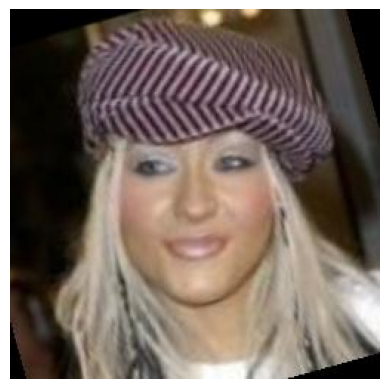

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/Colab Notebooks/archive/lfw-deepfunneled/lfw-deepfunneled/Christina_Aguilera/Christina_Aguilera_0001.jpg"

img = Image.open(img_path)

print("Image size:", img.size)

plt.imshow(img)
plt.axis('off')
plt.show()

In [10]:
import torchvision
print(torchvision.__version__)

0.26.0+cpu


In [11]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="/content/drive/MyDrive/Colab Notebooks/archive/lfw-deepfunneled/lfw-deepfunneled",
    transform=transform,
    allow_empty=True
)

print("Dataset size:", len(dataset))
print("Number of classes:", len(dataset.classes))

Dataset size: 13281
Number of classes: 5784


In [12]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(dataloader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])


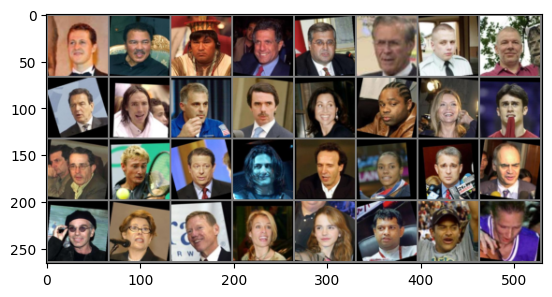

In [13]:
# Define transformations for the dataset
transform = transforms.Compose([
    transforms.Resize(64),#Resize images to 64*64
    transforms.CenterCrop(64),#Crop the central part of the image
    transforms.ToTensor(),#Convert images to tensors
    transforms.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5])#Normalize the images
])
#Load the LFW dataset
dataset = datasets.ImageFolder(
    root="/content/drive/MyDrive/Colab Notebooks/archive/lfw-deepfunneled/lfw-deepfunneled",
    transform=transform,
    allow_empty=True
)
dataloader=DataLoader(dataset,batch_size=32,shuffle=True)
#function to unnoormalize and display images
def imshow(img):
  img=img/2+0.5   #unormalize
  npimg=img.numpy()
  plt.imshow(np.transpose(npimg,(1,2,0)))
  plt.show()
#get a batch of images
dataiter=iter(dataloader)
images,_=next(dataiter)
#show images
imshow(vutils.make_grid(images))
